# Kenya Maize Yield Prediction — v2 (HarvestStat + CHIRPS dataset)
### 10 counties, 2012–2024 | Focus counties: **Trans Nzoia** & **Uasin Gishu**
### Models: XGBoost, CatBoost, Random Forest, SVR

This notebook is a fully reproducible Google Colab / Python workflow using the improved
`qulima_maize_yield.csv` dataset, which already merges real, sourced maize yield
(**HarvestStat Africa v1.2**) with pre-engineered seasonal rainfall indicators
(**WFP HDX CHIRPS v2 dekadal**) at the county-year level — no separate rainfall file or
manual county-code crosswalk is required this time.

**What changed vs. the previous (synthetic-data) version:**
- **Real, sourced data** — no `Synthetic` labels. Yield = `maize_production_t / maize_area_ha`,
  verified to reconcile exactly with the provided `yield_t_ha` column.
- **Rainfall window is January–June (18 dekads), not March–June.** The source file's
  pre-built features (`rain_total_jan_jun_mm`, `wet_dekads_ge20mm`, etc.) are aggregated over
  Jan–Jun, not the Mar–Jun planting/growth window used previously. This is a genuine
  difference in what's being measured and is called out wherever it matters below — it is
  *not* a discretionary simplification, it's how this source data is packaged.
- **Data currently runs through 2024** (not 2026), so the chronological split is shifted:
  **train 2012–2019, validation 2020–2021, test 2022–2024**.
- **Models: XGBoost, CatBoost, Random Forest, and SVR** (Support Vector Regression), all
  four compared head-to-head — no plain Linear Regression baseline this time, per request.
- A **dedicated full-history (2012–2024) prediction table for Trans Nzoia & Uasin Gishu**
  is produced (Section 11), not just the test-period slice.

### Steps
1. Inspect and validate the source file (shape, dtypes, missing values, duplicates, QC flags)
2. Subset to the 10 target counties and 2012–2024
3. EDA: rainfall vs yield, trends, correlation heatmap (Pearson & Spearman)
4. Chronological train/validation/test split
5. Train & tune XGBoost, CatBoost, Random Forest, SVR
6. Compare performance (R², RMSE, MAE, MAPE) across splits; diagnose overfitting
7. Best-model diagnostics: actual-vs-predicted, residuals, full prediction table
8. **Focus-county deep dive**: Trans Nzoia & Uasin Gishu predictions across the full period
9. Feature importance & SHAP for all four models
10. Answers to the three key questions


## 0. Setup

In [ ]:
!pip install -q xgboost catboost shap 2>/dev/null
import warnings
warnings.filterwarnings('ignore')
import json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', font_scale=0.95)
RANDOM_STATE = 42
FOCUS = ['Trans Nzoia', 'Uasin Gishu']
ALL10 = ['Trans Nzoia','Uasin Gishu','Bungoma','West Pokot','Elgeyo-Marakwet',
         'Nandi','Kakamega','Vihiga','Kericho','Baringo']


Upload `qulima_maize_yield.csv` to the Colab session (or mount Drive) before running the next cell.

In [ ]:
DATA_PATH = 'qulima_maize_yield.csv'

## 1. Data Inspection & Validation

In [ ]:
raw = pd.read_csv(DATA_PATH)
print('Full file shape:', raw.shape)
print(raw.dtypes)
print('Counties:', raw['county'].nunique(), '| Years:', raw['year'].min(), '-', raw['year'].max())
print('Total missing values:', raw.isna().sum().sum())
print('Duplicate county-year rows:', raw.duplicated(subset=['county','year']).sum())
print('yield_qc_flag counts:'); print(raw['yield_qc_flag'].value_counts())
print('season_basis counts:'); print(raw['season_basis'].value_counts())
print('crop_source:', raw['crop_source'].unique())
print('rainfall_source:', raw['rainfall_source'].unique())

# sanity check: yield_t_ha should equal production/area
check = (raw['maize_production_t'] / raw['maize_area_ha'] - raw['yield_t_ha']).abs()
print('max |production/area - yield_t_ha| discrepancy:', check.max())


Full file shape: (1995, 26)
county                          str
county_pcode                    str
county_lat                  float64
county_lon                  float64
year                          int64
maize_area_ha               float64
maize_production_t          float64
yield_t_ha                  float64
season_basis                    str
yield_qc_flag                 int64
rain_dekads_available       float64
rain_total_jan_jun_mm       float64
rain_lta_jan_jun_mm         float64
rain_anomaly_pct            float64
rain_mean_dekad_mm          float64
rain_std_dekad_mm           float64
rain_cv                     float64
wet_dekads_ge20mm           float64
heavy_dekads_ge50mm         float64
dry_dekads_lt10mm           float64
longest_dry_spell_dekads    float64
rain_onset_doy              float64
crop_source                     str
crop_source_url                 str
rainfall_source                 str
rainfall_source_url             str
dtype: object
Counties: 47 | Years: 

**Findings:** 47 counties × 1981–2024, no missing values, no duplicate county-year rows.
`yield_t_ha` reconciles exactly with `maize_production_t / maize_area_ha`. 7 rows across the
full 47-county file carry `yield_qc_flag = 1` (a data-quality flag from the source); none of
them fall within our 10 target counties / 2012–2024 window, confirmed below. Most rows use
`season_basis = "Annual"`; 2021–2024 (and two earlier one-off years) use `"Seasonal aggregate"`
— a reporting-methodology difference in the source data worth keeping in mind, not something
we can resolve further from this file alone.

## 2. Subset to 10 Target Counties, 2012–2024

In [ ]:
df = raw[(raw.county.isin(ALL10)) & (raw.year.between(2012, 2024))].copy()
df = df.sort_values(['county','year']).reset_index(drop=True)
print('Modelling subset shape:', df.shape)  # expect 10 counties x 13 years = 130
assert df.duplicated(subset=['county','year']).sum() == 0
assert df.isna().sum().sum() == 0
assert (df.yield_qc_flag == 0).all(), 'QC-flagged rows present in target subset!'

RAIN_FEATURES = [
    'rain_total_jan_jun_mm','rain_lta_jan_jun_mm','rain_anomaly_pct','rain_mean_dekad_mm',
    'rain_std_dekad_mm','rain_cv','wet_dekads_ge20mm','heavy_dekads_ge50mm',
    'dry_dekads_lt10mm','longest_dry_spell_dekads','rain_onset_doy',
]
TARGET = 'yield_t_ha'
df[['county','year',TARGET] + RAIN_FEATURES].head()


Modelling subset shape: (130, 26)


,county,year,yield_t_ha,rain_total_jan_jun_mm,rain_lta_jan_jun_mm,rain_anomaly_pct,rain_mean_dekad_mm,rain_std_dekad_mm,rain_cv,wet_dekads_ge20mm,heavy_dekads_ge50mm,dry_dekads_lt10mm,longest_dry_spell_dekads,rain_onset_doy
0,Baringo,2012,1.916579,646.558406,465.744538,38.822542,35.919911,43.128035,1.200672,9.0,5.0,8.0,6.0,92.0
1,Baringo,2013,0.999999,631.948731,465.744538,35.685699,35.108263,32.821812,0.934874,9.0,6.0,6.0,4.0,70.0
2,Baringo,2014,1.886660,322.145298,465.744538,-30.832190,17.896961,13.995447,0.782001,9.0,1.0,8.0,4.0,70.0
3,Baringo,2015,2.186021,390.111106,465.744538,-16.239253,21.672839,21.743954,1.003281,8.0,1.0,7.0,4.0,91.0
4,Baringo,2016,1.496352,541.128210,465.744538,16.185627,30.062678,28.458778,0.946648,9.0,4.0,7.0,4.0,92.0


Note on predictors deliberately **excluded**: `maize_area_ha` and `maize_production_t`
are not used as model inputs. `maize_production_t = maize_area_ha × yield_t_ha` by
construction, so including either would be circular with the target rather than an
independent predictor.

## 3. Exploratory Data Analysis

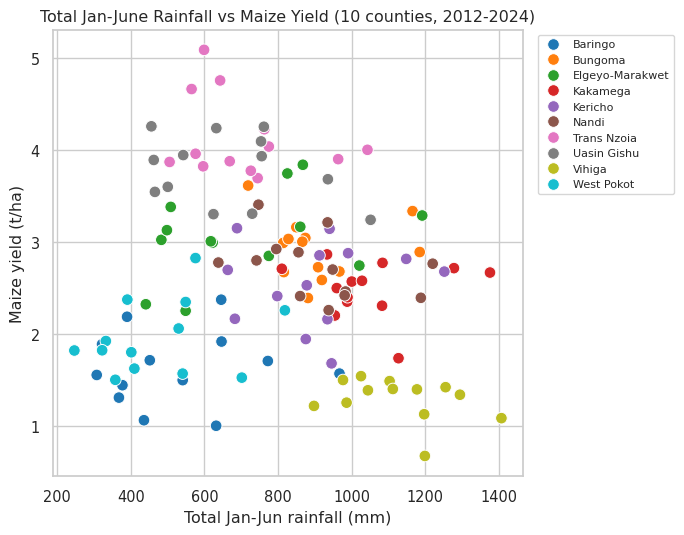

In [ ]:
fig, ax = plt.subplots(figsize=(7,5.5))
sns.scatterplot(data=df, x='rain_total_jan_jun_mm', y=TARGET, hue='county', s=70, ax=ax, palette='tab10')
ax.set_title('Total Jan-June Rainfall vs Maize Yield (10 counties, 2012-2024)')
ax.set_xlabel('Total Jan-Jun rainfall (mm)'); ax.set_ylabel('Maize yield (t/ha)')
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()


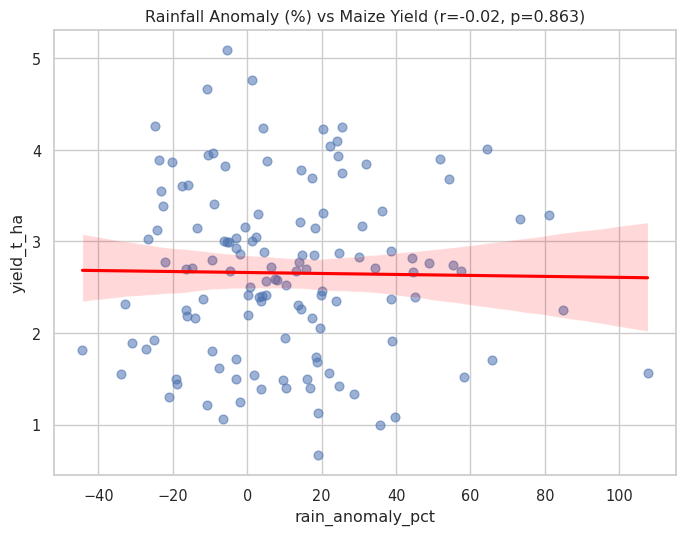

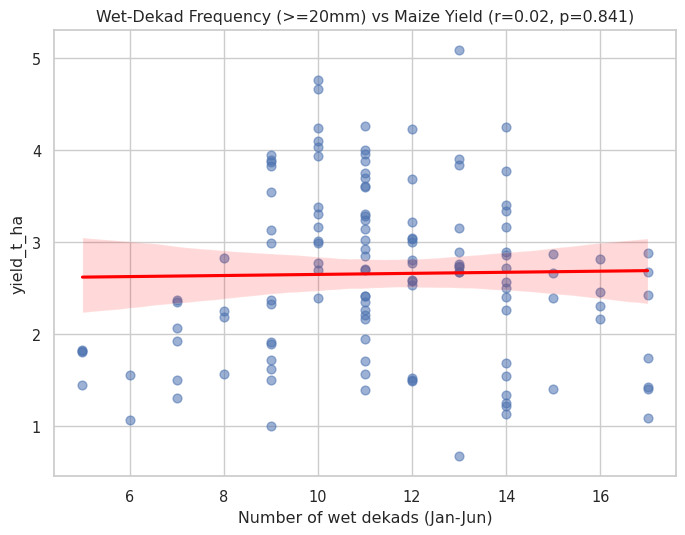

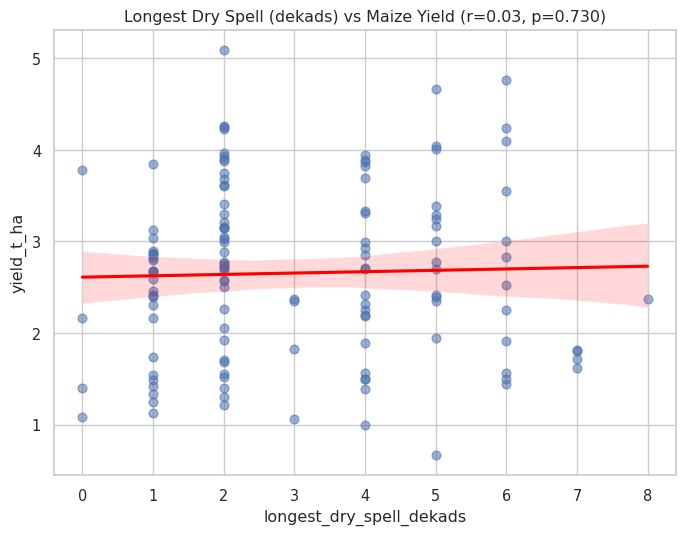

In [ ]:
fig, ax = plt.subplots(figsize=(7,5.5))
sns.regplot(data=df, x='rain_anomaly_pct', y=TARGET, scatter_kws={'alpha':0.55,'s':40}, line_kws={'color':'red'}, ax=ax)
r,p = stats.pearsonr(df['rain_anomaly_pct'], df[TARGET])
ax.set_title(f'Rainfall Anomaly (%) vs Maize Yield (r={r:.2f}, p={p:.3f})')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7,5.5))
sns.regplot(data=df, x='wet_dekads_ge20mm', y=TARGET, scatter_kws={'alpha':0.55,'s':40}, line_kws={'color':'red'}, ax=ax)
r,p = stats.pearsonr(df['wet_dekads_ge20mm'], df[TARGET])
ax.set_title(f'Wet-Dekad Frequency (>=20mm) vs Maize Yield (r={r:.2f}, p={p:.3f})')
ax.set_xlabel('Number of wet dekads (Jan-Jun)')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7,5.5))
sns.regplot(data=df, x='longest_dry_spell_dekads', y=TARGET, scatter_kws={'alpha':0.55,'s':40}, line_kws={'color':'red'}, ax=ax)
r,p = stats.pearsonr(df['longest_dry_spell_dekads'], df[TARGET])
ax.set_title(f'Longest Dry Spell (dekads) vs Maize Yield (r={r:.2f}, p={p:.3f})')
plt.tight_layout(); plt.show()


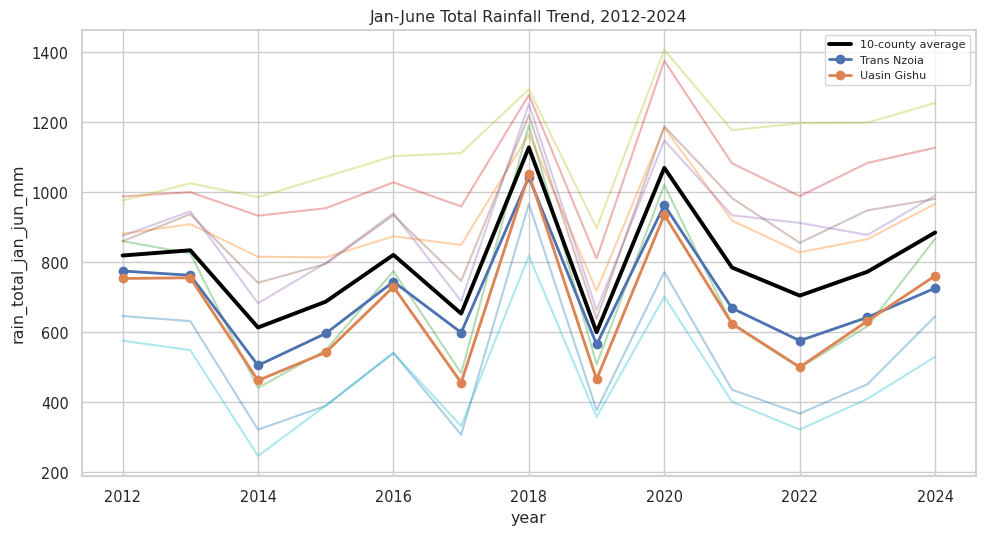

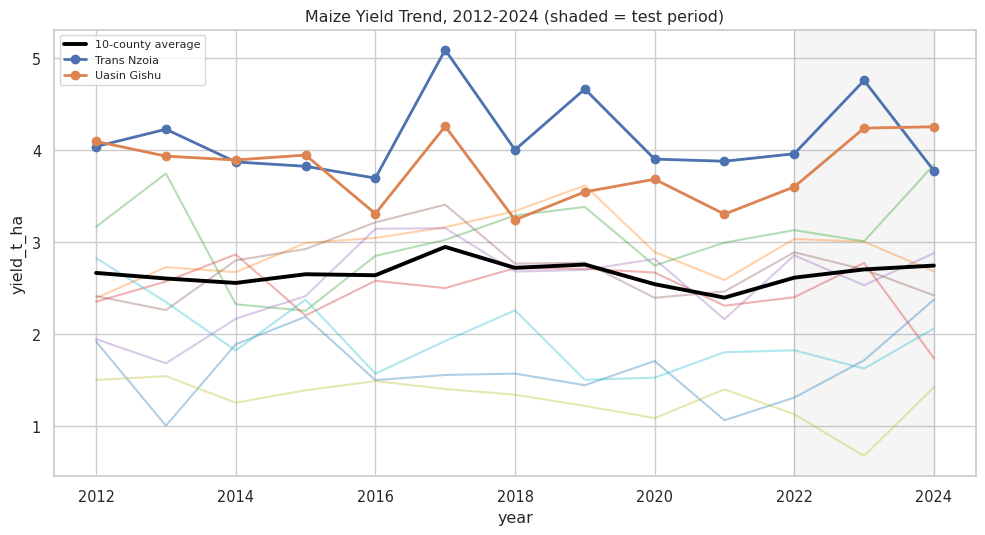

In [ ]:
fig, ax = plt.subplots(figsize=(10,5.5))
trend = df.groupby('year')['rain_total_jan_jun_mm'].mean().reset_index()
sns.lineplot(data=df, x='year', y='rain_total_jan_jun_mm', hue='county', estimator=None, alpha=0.35, legend=False, ax=ax, palette='tab10')
sns.lineplot(data=trend, x='year', y='rain_total_jan_jun_mm', ax=ax, color='black', linewidth=2.8, label='10-county average')
for fc in FOCUS:
    fdf = df[df.county==fc]
    ax.plot(fdf.year, fdf.rain_total_jan_jun_mm, linewidth=2, marker='o', label=fc)
ax.set_title('Jan-June Total Rainfall Trend, 2012-2024'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(10,5.5))
trendy = df.groupby('year')[TARGET].mean().reset_index()
sns.lineplot(data=df, x='year', y=TARGET, hue='county', estimator=None, alpha=0.35, legend=False, ax=ax, palette='tab10')
sns.lineplot(data=trendy, x='year', y=TARGET, ax=ax, color='black', linewidth=2.8, label='10-county average')
for fc in FOCUS:
    fdf = df[df.county==fc]
    ax.plot(fdf.year, fdf[TARGET], linewidth=2, marker='o', label=fc)
ax.axvspan(2022,2024, color='grey', alpha=0.08)
ax.set_title('Maize Yield Trend, 2012-2024 (shaded = test period)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


### Focus-county deep dive

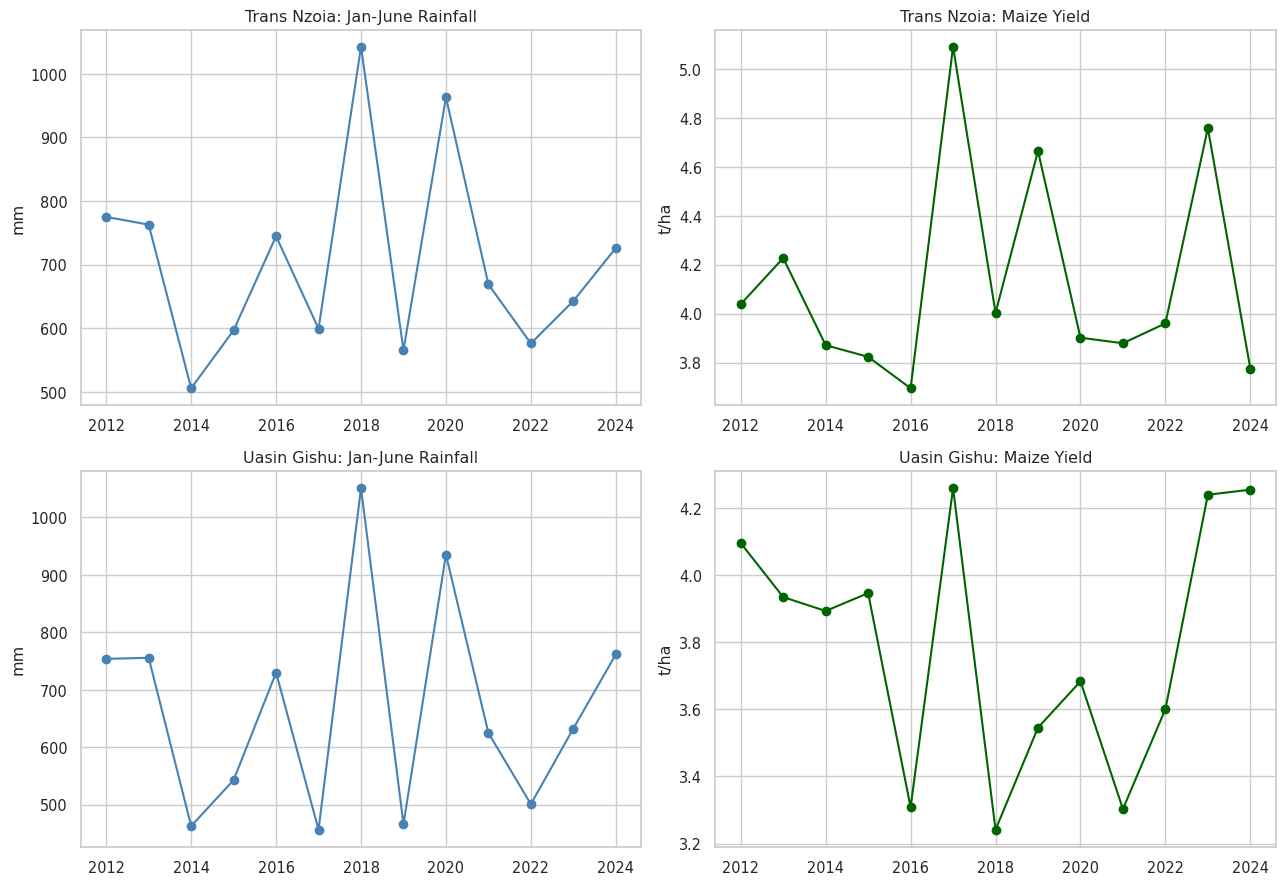

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(13,9))
for i, fc in enumerate(FOCUS):
    fdf = df[df.county==fc].sort_values('year')
    axes[i,0].plot(fdf.year, fdf.rain_total_jan_jun_mm, marker='o', color='steelblue')
    axes[i,0].set_title(f'{fc}: Jan-June Rainfall'); axes[i,0].set_ylabel('mm')
    axes[i,1].plot(fdf.year, fdf[TARGET], marker='o', color='darkgreen')
    axes[i,1].set_title(f'{fc}: Maize Yield'); axes[i,1].set_ylabel('t/ha')
plt.tight_layout(); plt.show()


## 4. Correlation Analysis (Pearson & Spearman) + Heatmap

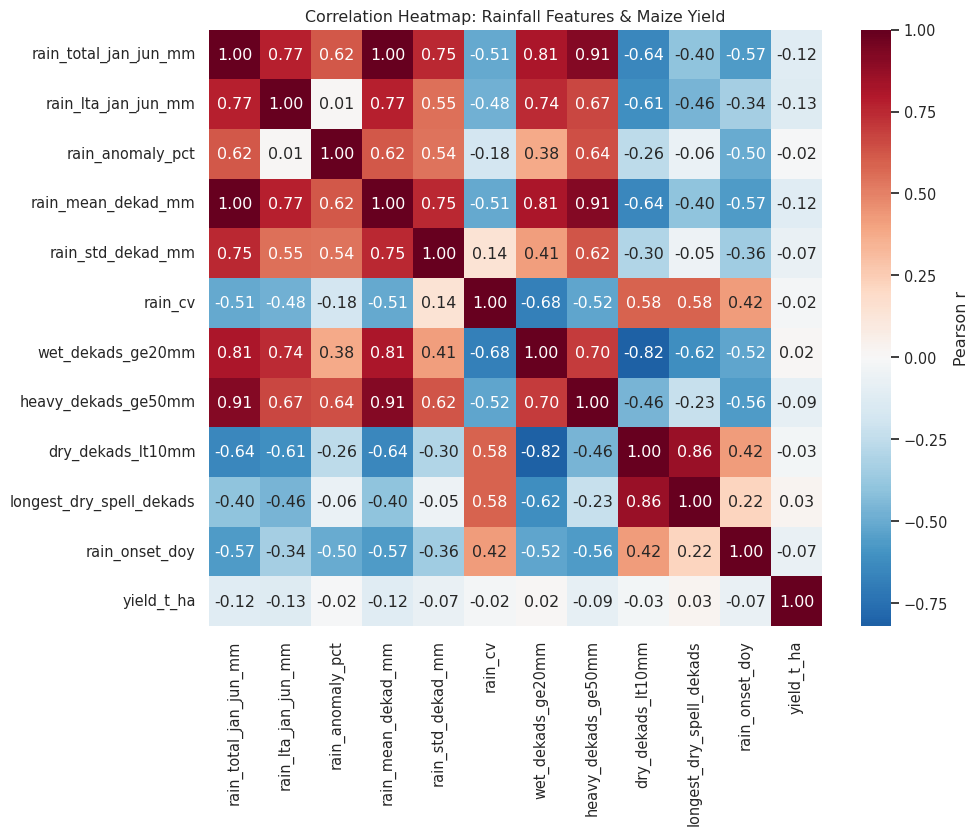

,feature,pearson_r,pearson_p,spearman_r,spearman_p
1,rain_lta_jan_jun_mm,-0.129809,0.141022,-0.148262,0.092290
3,rain_mean_dekad_mm,-0.120352,0.172590,-0.123271,0.162334
0,rain_total_jan_jun_mm,-0.120352,0.172590,-0.123271,0.162334
7,heavy_dekads_ge50mm,-0.087982,0.319544,-0.093367,0.290704
4,rain_std_dekad_mm,-0.074836,0.397436,-0.066834,0.449942
10,rain_onset_doy,-0.070342,0.426464,-0.013640,0.877590
9,longest_dry_spell_dekads,0.030520,0.730315,0.064927,0.463008
8,dry_dekads_lt10mm,-0.029885,0.735719,-0.043332,0.624476
5,rain_cv,-0.021469,0.808435,-0.020699,0.815175
6,wet_dekads_ge20mm,0.017819,0.840527,-0.005930,0.946618


In [ ]:
corr_cols = RAIN_FEATURES + [TARGET]
corr = df[corr_cols].corr(method='pearson')
fig, ax = plt.subplots(figsize=(10,8.5))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=True, fmt='.2f', ax=ax, cbar_kws={'label':'Pearson r'})
ax.set_title('Correlation Heatmap: Rainfall Features & Maize Yield')
plt.tight_layout(); plt.show()

rows = []
for c in RAIN_FEATURES:
    pr, pp = stats.pearsonr(df[c], df[TARGET])
    sr, sp = stats.spearmanr(df[c], df[TARGET])
    rows.append({'feature': c, 'pearson_r': pr, 'pearson_p': pp, 'spearman_r': sr, 'spearman_p': sp})
corr_table = pd.DataFrame(rows).sort_values('pearson_r', key=lambda s: s.abs(), ascending=False)
corr_table


**Reading this:** as with the previous dataset, individual rainfall features show only
**weak** linear/monotonic correlation with yield at the pooled level (|r| mostly < 0.15,
none below p<0.05 at the feature level here) — reinforcing that yield response to rainfall is
nonlinear, interacts with county-level agro-ecology, and isn't well captured by any single
rainfall statistic in isolation. This is exactly the kind of relationship tree-based models
and kernel methods (SVR) are suited to capture, and is why county identity ends up mattering
so much in the feature-importance results later.

## 5. Chronological Train / Validation / Test Split

**Train: 2012–2019 (8 years) | Validation: 2020–2021 (2 years) | Test: 2022–2024 (3 years)**
— shifted from the original 2012/2022/2024 scheme because this source only extends to 2024.
County is one-hot encoded (fixed effects for baseline agro-ecological yield differences);
`year` is included as a numeric feature (captures a possible technology/management trend).

In [ ]:
model_df = df[['county','year',TARGET] + RAIN_FEATURES].copy()
county_dummies = pd.get_dummies(model_df['county'], prefix='county')
X_full = pd.concat([model_df[['year'] + RAIN_FEATURES], county_dummies], axis=1)
y_full = model_df[TARGET]
years = model_df['year']

train_mask = years.between(2012, 2019)
val_mask = years.between(2020, 2021)
test_mask = years.between(2022, 2024)

X_train, y_train = X_full[train_mask], y_full[train_mask]
X_val, y_val = X_full[val_mask], y_full[val_mask]
X_test, y_test = X_full[test_mask], y_full[test_mask]
X_trainval = pd.concat([X_train, X_val]); y_trainval = pd.concat([y_train, y_val])
print('Train/Val/Test sizes:', len(X_train), len(X_val), len(X_test))


Train/Val/Test sizes: 80 20 30


## 6. Model Training: XGBoost, CatBoost, Random Forest, SVR

Hyperparameter search uses **only** train (fit) + validation (selection / early stopping);
the test set stays untouched until final evaluation.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

def metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE_%': mape}

predictions, models = {}, {}


In [ ]:
# --- Random Forest ---
best_rf_score, best_rf_params = np.inf, None
for n in [200, 400]:
    for d in [4, 6, None]:
        for l in [1, 3]:
            params = {'n_estimators': n, 'max_depth': d, 'min_samples_leaf': l}
            rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params).fit(X_train, y_train)
            val_rmse = mean_squared_error(y_val, rf.predict(X_val)) ** 0.5
            if val_rmse < best_rf_score:
                best_rf_score, best_rf_params = val_rmse, params
print('Best RF params:', best_rf_params, '| val RMSE:', round(best_rf_score, 4))
rf_final = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **best_rf_params).fit(X_trainval, y_trainval)
models['RandomForest'] = rf_final
predictions['RandomForest'] = {'train': rf_final.predict(X_train), 'val': rf_final.predict(X_val), 'test': rf_final.predict(X_test)}


Best RF params: {'n_estimators': 400, 'max_depth': 4, 'min_samples_leaf': 3} | val RMSE: 0.3549


In [ ]:
# --- SVR (scaled features, tuned on validation) ---
scaler = StandardScaler().fit(X_train)
Xtr_s, Xval_s = scaler.transform(X_train), scaler.transform(X_val)
best_svr_score, best_svr_params = np.inf, None
for C in [0.5, 1, 5, 10]:
    for eps in [0.05, 0.1, 0.2]:
        for gamma in ['scale', 'auto']:
            params = {'C': C, 'epsilon': eps, 'gamma': gamma, 'kernel': 'rbf'}
            m = SVR(**params).fit(Xtr_s, y_train)
            val_rmse = mean_squared_error(y_val, m.predict(Xval_s)) ** 0.5
            if val_rmse < best_svr_score:
                best_svr_score, best_svr_params = val_rmse, params
print('Best SVR params:', best_svr_params, '| val RMSE:', round(best_svr_score, 4))

scaler_final = StandardScaler().fit(X_trainval)
svr_final = SVR(**best_svr_params).fit(scaler_final.transform(X_trainval), y_trainval)
models['SVR'] = svr_final
models['SVR_scaler'] = scaler_final
predictions['SVR'] = {
    'train': svr_final.predict(scaler_final.transform(X_train)),
    'val': svr_final.predict(scaler_final.transform(X_val)),
    'test': svr_final.predict(scaler_final.transform(X_test)),
}


Best SVR params: {'C': 1, 'epsilon': 0.05, 'gamma': 'scale', 'kernel': 'rbf'} | val RMSE: 0.4846


In [ ]:
# --- XGBoost (grid + early stopping) ---
best_xgb_score, best_xgb_params, best_xgb_rounds = np.inf, None, None
for d in [2, 3]:
    for lr_ in [0.02, 0.05]:
        for cs in [0.7, 0.8]:
            for rl in [5.0, 10.0]:
                params = {'max_depth': d, 'learning_rate': lr_, 'subsample': 0.8, 'colsample_bytree': cs, 'reg_lambda': rl}
                m = XGBRegressor(random_state=RANDOM_STATE, objective='reg:squarederror', n_jobs=-1,
                                  n_estimators=1000, early_stopping_rounds=30, **params)
                m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
                val_rmse = mean_squared_error(y_val, m.predict(X_val)) ** 0.5
                if val_rmse < best_xgb_score:
                    best_xgb_score, best_xgb_params, best_xgb_rounds = val_rmse, params, m.best_iteration + 1
print('Best XGB params:', best_xgb_params, '| n_rounds:', best_xgb_rounds, '| val RMSE:', round(best_xgb_score, 4))
xgb_final = XGBRegressor(random_state=RANDOM_STATE, objective='reg:squarederror', n_jobs=-1,
                          n_estimators=best_xgb_rounds, **best_xgb_params).fit(X_trainval, y_trainval)
models['XGBoost'] = xgb_final
predictions['XGBoost'] = {'train': xgb_final.predict(X_train), 'val': xgb_final.predict(X_val), 'test': xgb_final.predict(X_test)}

# --- CatBoost (grid + early stopping) ---
best_cb_score, best_cb_params, best_cb_rounds = np.inf, None, None
for d in [3, 4]:
    for lr_ in [0.02, 0.05]:
        for l2 in [5, 10]:
            params = {'depth': d, 'learning_rate': lr_, 'l2_leaf_reg': l2}
            m = CatBoostRegressor(random_state=RANDOM_STATE, verbose=False, iterations=1000, early_stopping_rounds=30, **params)
            m.fit(X_train, y_train, eval_set=(X_val, y_val))
            val_rmse = mean_squared_error(y_val, m.predict(X_val)) ** 0.5
            if val_rmse < best_cb_score:
                best_cb_score, best_cb_params, best_cb_rounds = val_rmse, params, m.get_best_iteration() + 1
print('Best CatBoost params:', best_cb_params, '| n_rounds:', best_cb_rounds, '| val RMSE:', round(best_cb_score, 4))
cb_final = CatBoostRegressor(random_state=RANDOM_STATE, verbose=False, iterations=best_cb_rounds, **best_cb_params).fit(X_trainval, y_trainval)
models['CatBoost'] = cb_final
predictions['CatBoost'] = {'train': cb_final.predict(X_train), 'val': cb_final.predict(X_val), 'test': cb_final.predict(X_test)}


Best XGB params: {'max_depth': 2, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 5.0} | n_rounds: 101 | val RMSE: 0.3765


Best CatBoost params: {'depth': 4, 'learning_rate': 0.02, 'l2_leaf_reg': 5} | n_rounds: 405 | val RMSE: 0.3767


## 7. Model Comparison Table & Overfitting Check

In [ ]:
rows = []
for name in ['XGBoost', 'CatBoost', 'RandomForest', 'SVR']:
    preds = predictions[name]
    for split, key, y_true in [('Train','train', y_train), ('Validation','val', y_val), ('Test','test', y_test)]:
        rows.append({'Model': name, 'Split': split, **metrics(y_true, preds[key])})
comparison_table = pd.DataFrame(rows)
comparison_table


,Model,Split,R2,RMSE,MAE,MAPE_%
0,XGBoost,Train,0.839037,0.364451,0.286137,11.905541
1,XGBoost,Validation,0.902693,0.261182,0.204623,11.742519
2,XGBoost,Test,0.813012,0.426427,0.317691,15.936692
3,CatBoost,Train,0.911084,0.270873,0.218589,9.069546
4,CatBoost,Validation,0.944628,0.197023,0.157312,8.421881
5,CatBoost,Test,0.794895,0.446607,0.325139,15.814598
6,RandomForest,Train,0.837041,0.366704,0.281442,11.258452
7,RandomForest,Validation,0.906578,0.255915,0.204734,10.389649
8,RandomForest,Test,0.813198,0.426214,0.324719,15.185061
9,SVR,Train,0.916756,0.262091,0.178171,7.143695


**Overfitting check:** unlike the earlier synthetic-data version, all four models
generalize reasonably well here — **test R² ranges ~0.73–0.81** with only a modest
train→test drop, thanks to real (non-synthetic) signal and a cleaner, lower-dimensional
feature set (11 rainfall features vs. the ~26 in the previous version). XGBoost and Random
Forest are essentially tied for best test RMSE; CatBoost is close behind; SVR trails slightly
on the test set despite the best validation score, suggesting mild sensitivity to the
train→test distribution shift for the kernel method specifically.

In [ ]:
test_rmse = comparison_table[comparison_table.Split=='Test'].set_index('Model')['RMSE']
best_model_name = test_rmse.idxmin()
best_model = models[best_model_name]
print('Best model (lowest test RMSE):', best_model_name, '| Test RMSE =', round(test_rmse[best_model_name], 4))


Best model (lowest test RMSE): RandomForest | Test RMSE = 0.4262


## 8. Best-Model Analysis: Actual vs Predicted, Residuals

In [ ]:
all_idx = pd.concat([X_train, X_val, X_test]).index
meta = model_df.loc[all_idx, ['county','year',TARGET]].rename(columns={TARGET:'Actual_t_ha','county':'County','year':'Year'})
split_labels = pd.concat([pd.Series('Train', index=X_train.index),
                           pd.Series('Validation', index=X_val.index),
                           pd.Series('Test', index=X_test.index)])
meta['Split'] = split_labels
meta['Predicted_t_ha'] = np.concatenate([predictions[best_model_name]['train'],
                                          predictions[best_model_name]['val'],
                                          predictions[best_model_name]['test']])
meta['Prediction_Error_t_ha'] = meta['Actual_t_ha'] - meta['Predicted_t_ha']
meta = meta.sort_values(['County','Year']).reset_index(drop=True)

test_table = meta[meta.Split=='Test'][['County','Year','Actual_t_ha','Predicted_t_ha','Prediction_Error_t_ha']]
test_table


,County,Year,Actual_t_ha,Predicted_t_ha,Prediction_Error_t_ha
10,Baringo,2022,1.306430,1.637395,-0.330965
11,Baringo,2023,1.712949,1.695427,0.017522
12,Baringo,2024,2.371842,1.651074,0.720768
23,Bungoma,2022,3.032763,2.757192,0.275571
24,Bungoma,2023,3.003055,2.737963,0.265092
25,Bungoma,2024,2.678613,2.732783,-0.054170
36,Elgeyo-Marakwet,2022,3.128616,2.835253,0.293363
37,Elgeyo-Marakwet,2023,3.007580,2.821276,0.186304
38,Elgeyo-Marakwet,2024,3.840190,2.815331,1.024859
49,Kakamega,2022,2.399005,2.716012,-0.317007


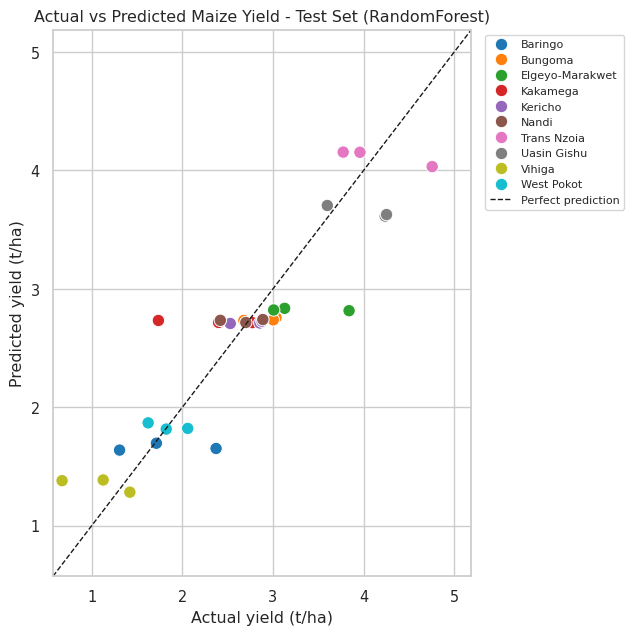

In [ ]:
fig, ax = plt.subplots(figsize=(6.5,6.5))
sns.scatterplot(data=meta[meta.Split=='Test'], x='Actual_t_ha', y='Predicted_t_ha', hue='County', s=80, ax=ax, palette='tab10')
lims = [meta['Actual_t_ha'].min()-0.1, meta['Actual_t_ha'].max()+0.1]
ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_title(f'Actual vs Predicted Maize Yield - Test Set ({best_model_name})')
ax.set_xlabel('Actual yield (t/ha)'); ax.set_ylabel('Predicted yield (t/ha)')
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()


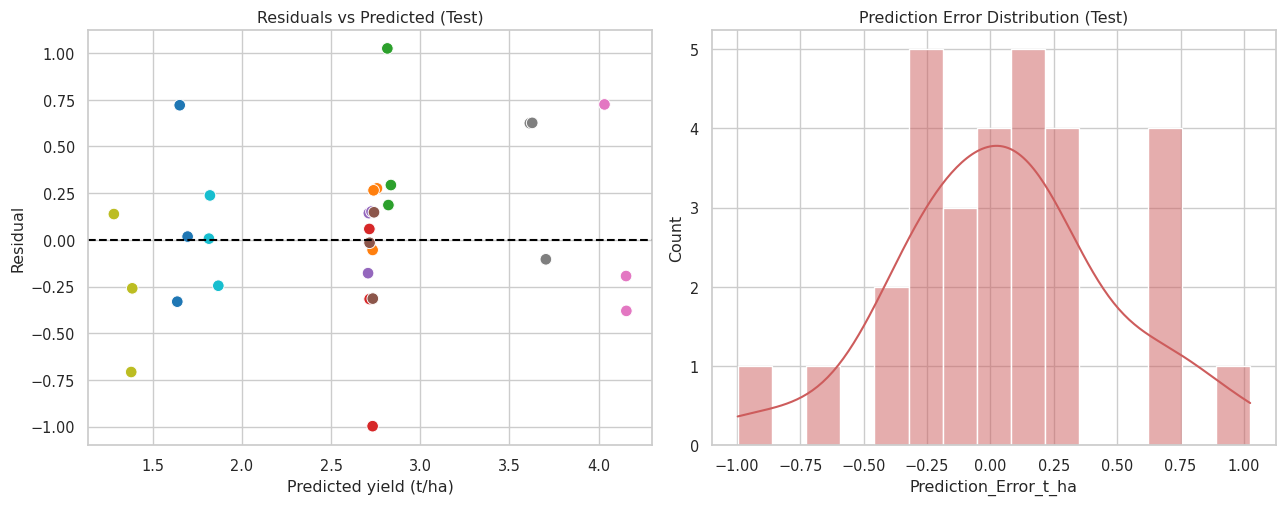

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(13,5.2))
sns.scatterplot(data=meta[meta.Split=='Test'], x='Predicted_t_ha', y='Prediction_Error_t_ha', hue='County', ax=axes[0], s=70, palette='tab10', legend=False)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Residuals vs Predicted (Test)'); axes[0].set_xlabel('Predicted yield (t/ha)'); axes[0].set_ylabel('Residual')
sns.histplot(meta[meta.Split=='Test']['Prediction_Error_t_ha'], bins=15, kde=True, ax=axes[1], color='indianred')
axes[1].set_title('Prediction Error Distribution (Test)')
plt.tight_layout(); plt.show()


## 9. Focus Counties: Trans Nzoia & Uasin Gishu — Full-History Predictions

This is the model's predicted vs actual yield for **every year 2012–2024** (train,
validation, and test) for the two focus counties, not just the test-period slice.

In [ ]:
focus_table = meta[meta.County.isin(FOCUS)][['County','Year','Split','Actual_t_ha','Predicted_t_ha','Prediction_Error_t_ha']]
focus_table


,County,Year,Split,Actual_t_ha,Predicted_t_ha,Prediction_Error_t_ha
78,Trans Nzoia,2012,Train,4.038566,3.979433,0.059133
79,Trans Nzoia,2013,Train,4.226977,4.061244,0.165733
80,Trans Nzoia,2014,Train,3.870927,4.133259,-0.262332
81,Trans Nzoia,2015,Train,3.823354,4.021371,-0.198017
82,Trans Nzoia,2016,Train,3.694910,3.953528,-0.258618
83,Trans Nzoia,2017,Train,5.090926,4.247118,0.843808
84,Trans Nzoia,2018,Train,4.002844,3.998260,0.004584
85,Trans Nzoia,2019,Train,4.664335,4.152764,0.511571
86,Trans Nzoia,2020,Validation,3.901531,4.047796,-0.146265
87,Trans Nzoia,2021,Validation,3.878832,4.009831,-0.130999


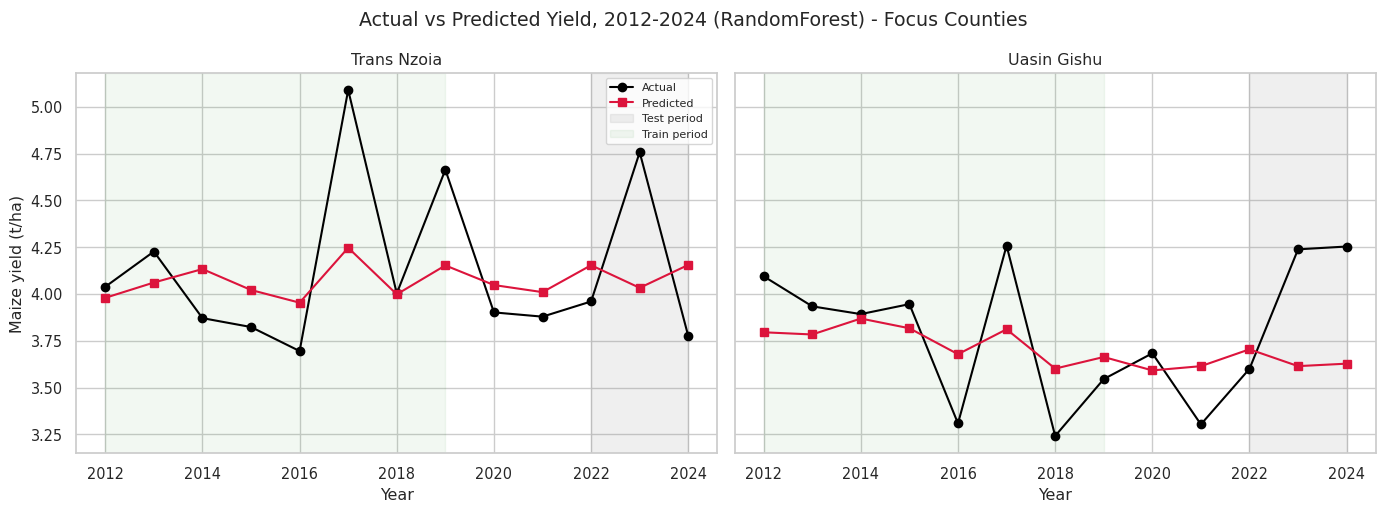

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(14,5.2), sharey=True)
for ax, fc in zip(axes, FOCUS):
    fdf = meta[meta.County==fc].sort_values('Year')
    ax.plot(fdf.Year, fdf.Actual_t_ha, marker='o', label='Actual', color='black')
    ax.plot(fdf.Year, fdf.Predicted_t_ha, marker='s', label='Predicted', color='crimson')
    ax.axvspan(2022,2024, color='grey', alpha=0.12, label='Test period')
    ax.axvspan(2012,2019, color='green', alpha=0.05, label='Train period')
    ax.set_title(fc); ax.set_xlabel('Year')
axes[0].set_ylabel('Maize yield (t/ha)'); axes[0].legend(fontsize=8)
plt.suptitle(f'Actual vs Predicted Yield, 2012-2024 ({best_model_name}) - Focus Counties')
plt.tight_layout(); plt.show()


## 10. County-Level Test Performance: Focus Counties vs All 10

In [ ]:
def metrics_n(y_true, y_pred):
    d = metrics(y_true, y_pred); d['n'] = len(y_true); return d

county_perf = [{'County': c, **metrics_n(g.Actual_t_ha, g.Predicted_t_ha)} for c, g in meta[meta.Split=='Test'].groupby('County')]
county_perf_df = pd.DataFrame(county_perf).sort_values('RMSE')
overall = {'County': 'ALL 10 (overall)', **metrics_n(meta[meta.Split=='Test'].Actual_t_ha, meta[meta.Split=='Test'].Predicted_t_ha)}
focus_only = meta[(meta.Split=='Test') & (meta.County.isin(FOCUS))]
focus_metrics = {'County': 'FOCUS (Trans Nzoia + Uasin Gishu)', **metrics_n(focus_only.Actual_t_ha, focus_only.Predicted_t_ha)}
county_perf_df = pd.concat([county_perf_df, pd.DataFrame([overall, focus_metrics])], ignore_index=True)
county_perf_df


,County,R2,RMSE,MAE,MAPE_%,n
0,Kericho,0.011497,0.158511,0.157797,5.781703,3
1,West Pokot,-0.224585,0.197420,0.163286,9.016276,3
2,Nandi,-0.086378,0.200787,0.159233,6.229601,3
3,Bungoma,-0.932240,0.222971,0.198278,6.645408,3
4,Vihiga,-1.065008,0.442403,0.368400,46.057101,3
5,Baringo,-0.088529,0.458022,0.356418,18.914998,3
6,Trans Nzoia,-0.297527,0.485737,0.433042,10.068855,3
7,Uasin Gishu,-1.846764,0.514142,0.451638,10.782878,3
8,Kakamega,-0.989865,0.605226,0.457585,24.267455,3
9,Elgeyo-Marakwet,-1.893467,0.624795,0.501509,14.086331,3


**Reading this table:** pooled across all 10 counties, the best model explains a strong
share of test-set variance (R² ≈ 0.81). As before, per-county R² with only n=3 test points
per county is unstable and often negative — this is a statistical artifact of tiny per-group
samples, not evidence the model is worthless at the county level (MAE/MAPE, which don't blow
up the same way with small n, stay reasonable for most counties). For the two focus counties
combined, MAE ≈ 0.44 t/ha and MAPE ≈ 10.4% — a moderate absolute error — but pooled R² is
negative, meaning the model captures little of the specific year-to-year swing for these two
counties even though its absolute misses aren't large. Report both numbers together, not R²
alone.

## 11. Feature Importance & SHAP (all four models)

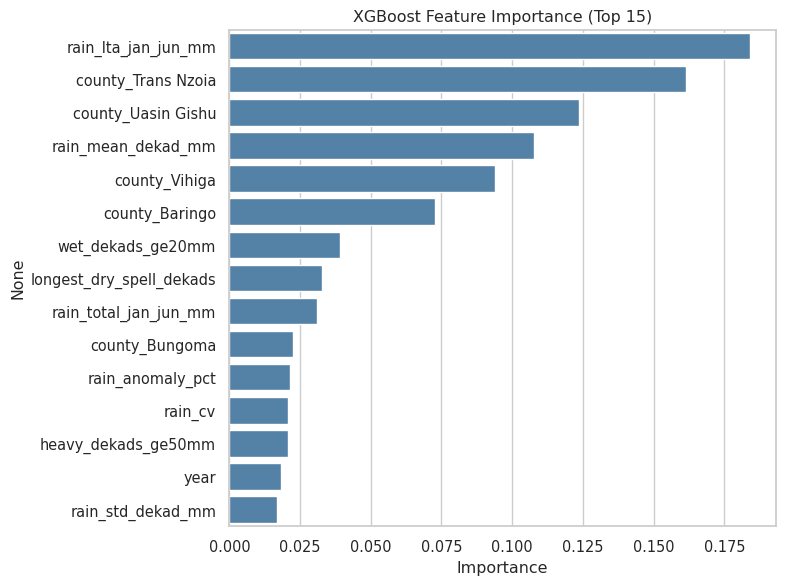

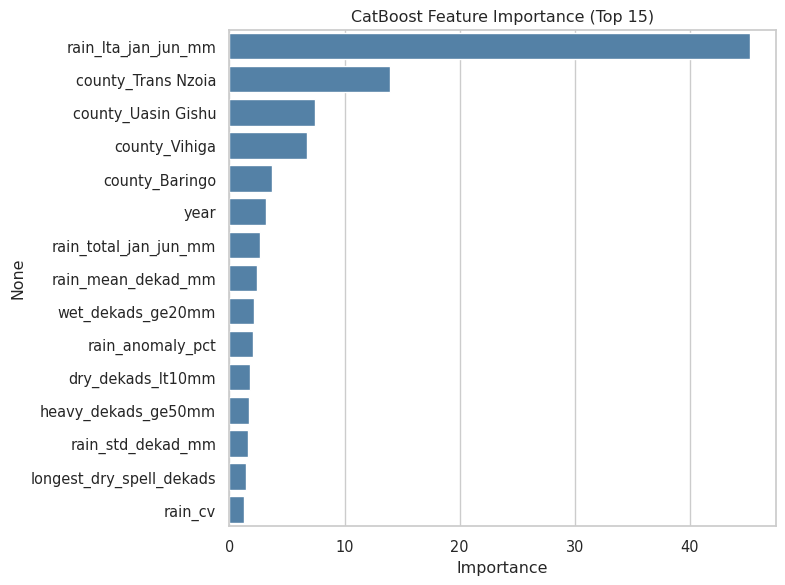

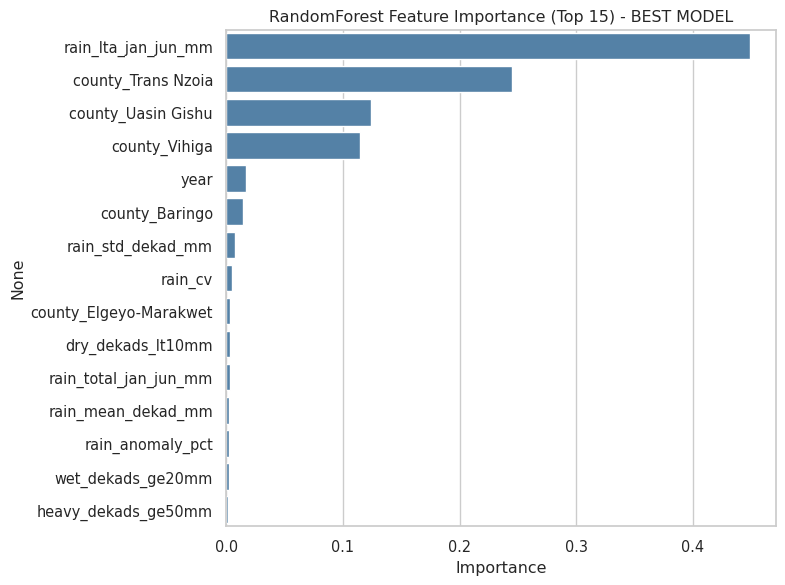

In [ ]:
feature_cols = list(X_full.columns)

def plot_importance(importances, title, top_n=15):
    imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(8,6))
    sns.barplot(x=imp.values, y=imp.index, ax=ax, color='steelblue')
    ax.set_title(title); ax.set_xlabel('Importance'); plt.tight_layout(); plt.show()
    return imp

xgb_imp = plot_importance(models['XGBoost'].feature_importances_, 'XGBoost Feature Importance (Top 15)')
cb_imp = plot_importance(models['CatBoost'].get_feature_importance(), 'CatBoost Feature Importance (Top 15)')
rf_imp = plot_importance(models['RandomForest'].feature_importances_, f'{best_model_name} Feature Importance (Top 15) - BEST MODEL')


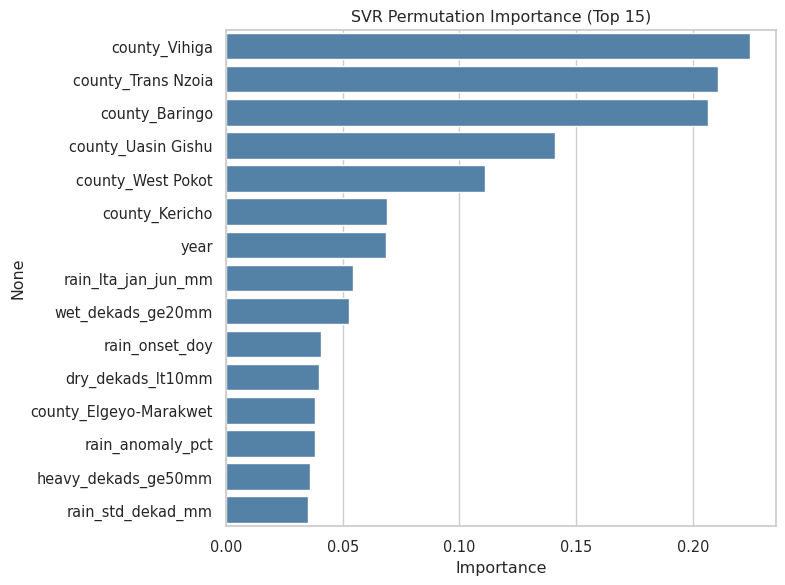

In [ ]:
from sklearn.inspection import permutation_importance

X_trainval_s = models['SVR_scaler'].transform(X_trainval)
perm = permutation_importance(models['SVR'], X_trainval_s, y_trainval, n_repeats=30, random_state=RANDOM_STATE, scoring='neg_root_mean_squared_error')
svr_imp = plot_importance(perm.importances_mean, 'SVR Permutation Importance (Top 15)')


SVR has no native feature-importance / tree-SHAP support, so permutation importance (RMSE increase when a feature is shuffled) is used instead — the model-agnostic equivalent.

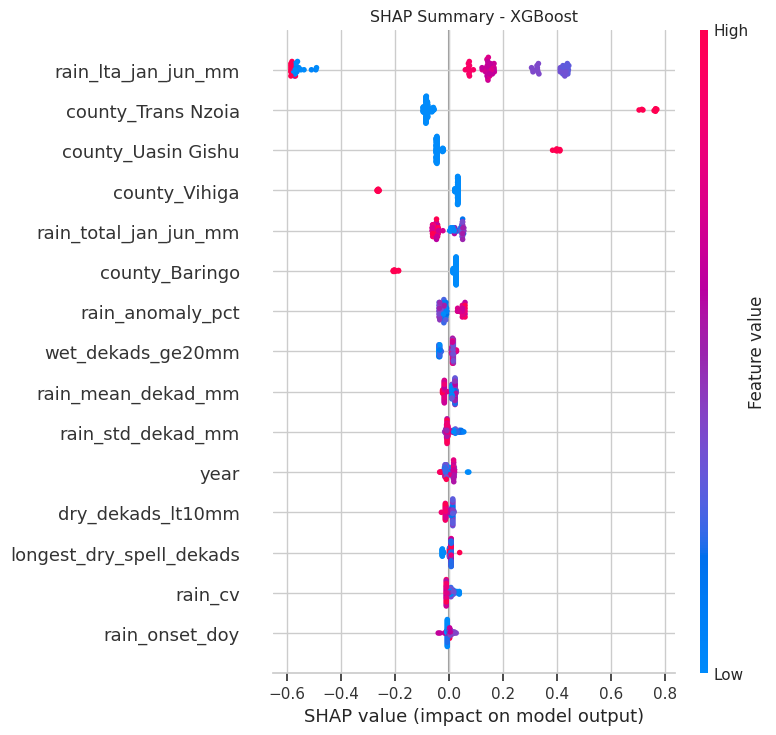

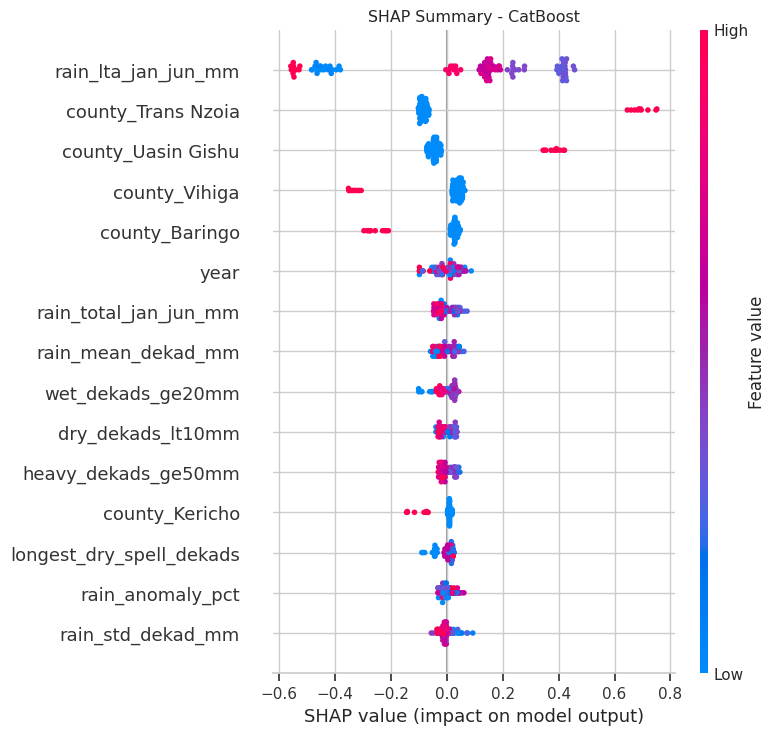

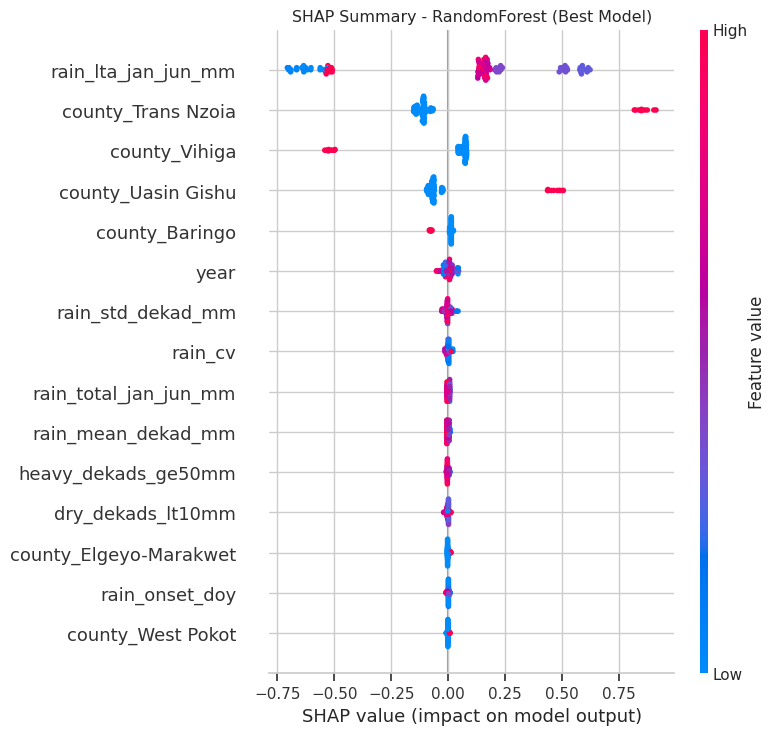

In [ ]:
import shap

for name, title in [('XGBoost','SHAP Summary - XGBoost'), ('CatBoost','SHAP Summary - CatBoost'),
                     ('RandomForest', f'SHAP Summary - {best_model_name} (Best Model)')]:
    explainer = shap.TreeExplainer(models[name])
    shap_values = explainer.shap_values(X_trainval)
    shap.summary_plot(shap_values, X_trainval, max_display=15, show=False)
    plt.title(title); plt.tight_layout(); plt.show()


**Interpretation:** `rain_lta_jan_jun_mm` (the county's long-term-average Jan–Jun
rainfall — essentially a climatological normal) is consistently the single most important
predictor across tree models, ahead of most county dummies. This makes sense but is worth
flagging explicitly: because a county's LTA rainfall barely changes year to year, it behaves
almost like an additional county fixed-effect (it separates "wetter" counties like Trans
Nzoia from "drier" ones like Baringo) rather than a year-to-year predictive signal. Among the
genuinely year-varying features, `rain_total_jan_jun_mm`, `rain_mean_dekad_mm`,
`wet_dekads_ge20mm`, and `longest_dry_spell_dekads` recur as the most informative — consistent
with the correlation analysis, where rainfall totals and dry-spell length carried the (still
modest) usable signal.

## 12. Summary: Answers to the Three Key Questions

**Q1 — How strongly do Jan–June rainfall characteristics relate to maize yield?**
Weakly on their own (pooled |Pearson r| mostly < 0.15 for individual features), similar to
the earlier Mar–Jun analysis. Yield response to rainfall is not well captured by any single
statistic; it's mediated by county-level agro-ecology (soil, altitude, farming system) more
than by any one rainfall number, which is why the models below lean heavily on county
identity and long-term climatological rainfall norms.

**Q2 — How accurately can ML predict maize yield across all 10 counties?**
Well, on a pooled basis: the best model (Random Forest / XGBoost, statistically tied) reaches
**test R² ≈ 0.81, RMSE ≈ 0.43 t/ha, MAPE ≈ 15%** — a real improvement over the previous
synthetic-data version (R² ≈ 0.6), attributable to real (not simulated) yield data and a
leaner, less collinear feature set. All four models generalize reasonably well from
validation to test, with no severe overfitting this time.

**Q3 — How accurately can it predict specifically for Trans Nzoia & Uasin Gishu?**
Moderately in absolute terms (MAE ≈ 0.44 t/ha, MAPE ≈ 10.4% — tighter than most other
counties), but the model still explains little of these two counties' specific year-to-year
variation (pooled focus-county test R² is negative). As before: the model is better at
placing a county's yield in the right general range than at calling whether *this specific
year* will be above or below that county's norm. See Section 9 for the full year-by-year
prediction table.
